# Credit Risk Scorecard - Data Exploration

Exploring the German Credit Dataset, loaded from SQL Server to have a better understanding on distributions and their relationship to credit risk ('Risk': good/bad)

In [1]:
import pyodbc
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

connection_string = (
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=AISHAMADIYAH\\SQLEXPRESS;"
    "Database=CreditRiskDB;"
    "Trusted_Connection=yes;"
)

connection = pyodbc.connect(connection_string)

query = "select * from credit_applications"
df = pd.read_sql(query, connection)
df = df.drop(columns=["column1"])

df.head()


,Age,Sex,Job,Housing,Saving_accounts,Checking_account,Credit_amount,Duration,Purpose,Risk
0,67,male,2,own,none,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,none,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


## Distribution of Age

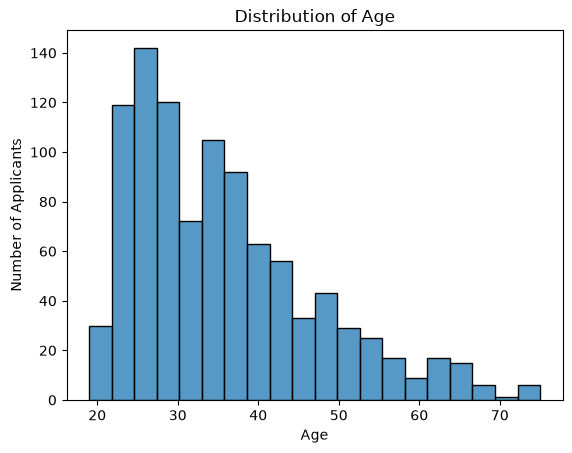

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Age"], bins=20) #builds a histogram of the age col & bins=20 splits the age range into 20 equal intervals
plt.title("Distribution of Age")
plt.ylabel("Number of Applicants")
plt.show()


## Age VS Risk

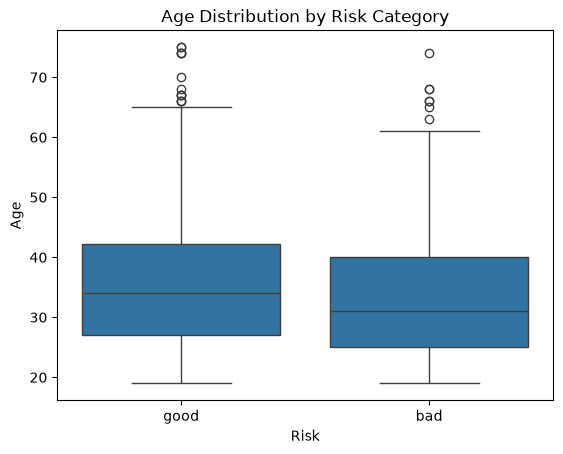

In [3]:
sns.boxplot(x="Risk", y="Age", data=df) #summarises a numeric column's spread within groups of a categorical column which is ideal compared to a histogram
plt.title("Age Distribution by Risk Category")
plt.show()

## Credit Amount VS Risk

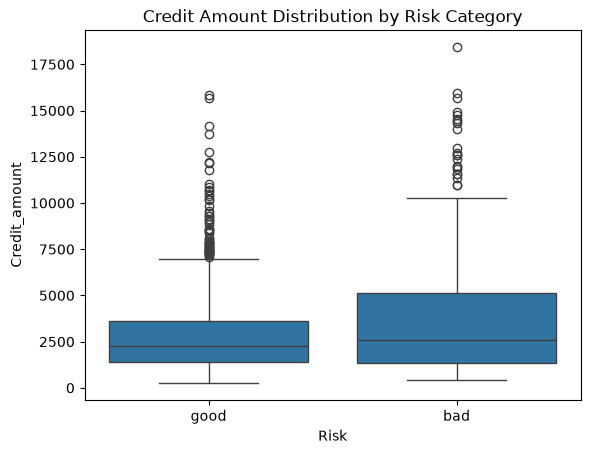

In [4]:
sns.boxplot(x="Risk", y="Credit_amount", data=df)
plt.title("Credit Amount Distribution by Risk Category")
plt.show()

## Train/Test Split

In [ ]:
import pkg_resources

import scorecardpy as sc #issue with this library, do not use

from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, stratify=df["Risk"], random_state=42)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.columns.tolist())
print(test.columns.tolist())

Train shape: (700, 10)
Test shape: (300, 10)
['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account', 'Credit_amount', 'Duration', 'Purpose', 'Risk']
['Age', 'Sex', 'Job', 'Housing', 'Saving_accounts', 'Checking_account', 'Credit_amount', 'Duration', 'Purpose', 'Risk']
